<a href="https://colab.research.google.com/github/takatakamanbou/AdvML/blob/2025/AdvML2025_ex14notebookA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AdvML ex14notebookA

<img width=72 src="https://www-tlab.math.ryukoku.ac.jp/~takataka/course/AdvML/AdvML-logo.png"> [この授業のウェブページ](https://www-tlab.math.ryukoku.ac.jp/wiki/?AdvML)




板書や口頭で補足する前提なので，この notebook だけでは説明が不完全です．


---
## 拡散モデル
---

---
### VAEの復習 + 階層化



VAE

潜在変数: $\pmb{z}$， 観測変数: $\pmb{x}$

- $\pmb{z}$ を条件としたときの $\pmb{x}$ の確率分布を $p_{\pmb{\theta}}(\pmb{x}|\pmb{z})$ として，ニューラルネットでモデル化（デコーダ）
- $\pmb{x}$ を条件としたときの $\pmb{z}$ の確率分布を $q_{\pmb{\phi}}(\pmb{z}|\pmb{x})$ として，ニューラルネットでモデル化（エンコーダ）

階層型VAE

潜在変数が $\pmb{z}_1, \pmb{z}_2$ の2つある階層型VAE

$\pmb{z}_2$ から $\pmb{z}_1$ が生成され，$\pmb{z}_1$ から $\pmb{x}$ が生成されると考える．$\pmb{z}_1$ は $\pmb{z}_2$ のみで条件付けられ，$\pmb{x}$ は $\pmb{z}_1$ のみで条件付けられる（マルコフ性がある）とする．

- $p_{\pmb{\theta}_2}(\pmb{z}_1|\pmb{z}_2), p_{\pmb{\theta}_1}(\pmb{x}|\pmb{z}_1)$ をそれぞれニューラルネットでモデル化（デコーダ）
- $q_{\pmb{\phi}_1}(\pmb{z}_1|\pmb{x}), q_{\pmb{\phi}_2}(\pmb{z}_2|\pmb{z}_1)$ をそれぞれニューラルネットでモデル化（エンコーダ）



一般化して，潜在変数が $\pmb{z}_1, \pmb{z}_2, \ldots, \pmb{z}_T$ の $T$ 個ある階層型VAEも考えられる．

- $p_{\pmb{\theta}_T}(\pmb{z}_{T-1}|\pmb{z}_T), \ldots, p_{\pmb{\theta}_2}(\pmb{z}_1|\pmb{z}_2), p_{\pmb{\theta}_1}(\pmb{x}|\pmb{z}_1)$
- $q_{\pmb{\phi}_1}(\pmb{z}_1|\pmb{x}), q_{\pmb{\phi}_2}(\pmb{z}_2|\pmb{z}_1), \ldots, q_{\pmb{\phi}_T}(\pmb{z}_T|\pmb{z}_{T-1})$

潜在変数を階層化することで，より複雑な分布を表現できると期待されるが，エンコーダデコーダ一つずつから成るVAEと比べると，エンコーダもデコーダも $T$ 個必要となる．
そのため，$T$の大きな階層型VAEを実現するのは，現実には難しい．

---
### 拡散モデルとは



**拡散モデル**（Diffusion Model, 注）には様々なものがあるが，ここではその一つである， **Denoising Diffusion Probabilistic Model** (DDPM)というモデルについて説明する．

<hr width="50%" align="left">
<span style="font-size: 75%">
※ 注意: ここで説明している「拡散モデル」は，機械学習/深層学習の分野で最近出てきたものである．
一方，数理科学の分野では，様々な現象を記述するモデルとして昔から「拡散モデル」という語が存在している（拡散方程式, etc.）．両者は異なるものであることに注意．
</span>


拡散モデルは，階層型VAEを次のように変更したものと考えることができる．

- 観測変数と潜在変数の次元数が等しい
- エンコーダに相当する処理が，パラメータ固定の正規分布に従うノイズを加える計算で表される

このような変更を加えることで，$T=1000$ といった非常に深い階層の潜在変数モデルを実現できる．

拡散モデルでは，観測変数と潜在変数の次元数が等しいことから，どちらも $\pmb{x}$ という記号で表すことが多い．ここでは，観測変数を $\pmb{x}_0$ を表し，潜在変数を $\pmb{x}_1, \pmb{x}_2, \ldots, \pmb{x}_T$ と表す．$\pmb{x}_T$ から $\pmb{x}_{T-1}$ が生成され，...，$\pmb{x}_2$ から $\pmb{x}_1$ が生成され，$\pmb{x}_1$ から $\pmb{x}_0$ が生成されると考える．

---
### 拡散過程と逆拡散過程


拡散モデルの計算は，データにノイズを加えていく過程と，加えられたノイズを取り除いていく過程からできていると解釈することができる．
前者を拡散過程といい，後者を逆拡散過程という．

#### 拡散過程

拡散モデルでは，階層型VAEにおける $\pmb{z}_{t-1}$ から $\pmb{z}_{t}$ を求める計算が，「時刻 $t-1$ のデータ $\pmb{x}_{t-1}$ にガウシアンノイズ（正規分布に従うノイズ）を加えて時刻 $t$ のデータ $\pmb{x}_{t}$ を得る」計算に置き換えられる．
この計算の過程を拡散過程という．

階層型VAEでは， $q_{\pmb{\phi}_t}(\pmb{z}_t|\pmb{z}_{t-1})$ をパラメータ $\pmb{\phi}_t$ をもつニューラルネット（1つのエンコーダ）でモデル化していたが，拡散モデルでは，$q(\pmb{x}_t|\pmb{x}_{t-1})$ はパラメータ固定の正規分布で表される．
典型的には，$q(\pmb{x}_t|\pmb{x}_{t-1}) $ が次式に従うと考える．

$$
q(\pmb{x}_t|\pmb{x}_{t-1}) = N\left(\pmb{x}_{t}; \sqrt{1-\beta_t}\pmb{x}_{t-1}, \beta_tI\right) \qquad (t = 1, 2, \ldots, T)
$$

$\beta_t$ は $0$ 以上 $1$ 以下であらかじめ設定する値である．$\pmb{x}_{t-1}$ の値が与えられたときに，この正規分布に従う $\pmb{x}_{t}$ のサンプルを得るには， 次のようにすればよい．

$$
\begin{aligned}
\pmb{\varepsilon} &\sim N(\pmb{0}, I) \\
\pmb{x}_t &= \sqrt{1-\beta_t}\pmb{x}_{t-1} + \sqrt{\beta_t}\pmb{\varepsilon}
\end{aligned}
$$

例えば，$\beta_t = 0.01$ の場合，$\pmb{x}_t = 0.995\pmb{x}_{t-1} + 0.1\pmb{\varepsilon}$ となり，前の時刻のデータを少しだけ小さくしてから小さなガウシアンノイズを加えることになる．

このように $q(\pmb{x}_t|\pmb{x}_{t-1})$ を定めたときに，$T$ を十分大きくし，かつ $\beta_1, \beta_2, \ldots, \beta_T$ がある条件を満たすように定めると，$p(\pmb{x}_T) \approx N(\pmb{x}_T; \pmb{0}, I)$ となることが知られている．

<img src="https://www-tlab.math.ryukoku.ac.jp/~takataka/course/AdvML/diffusion.png">

左上の画像に拡散過程を適用していった結果．「Noise: t」の直下の画像は，$\pmb{x}_t$ に相当する．

#### 逆拡散過程

逆拡散過程では，データ $\pmb{x}_t$ からノイズを少し取り除いたデータ $\pmb{x}_{t-1}$ を求める．
この過程の $T$ 回の繰り返しによって，標準正規分布に従う潜在変数 $\pmb{x}_T$ から観測変数 $\pmb{x}_0$ が生成される過程をモデル化する．
拡散モデルでは，$\pmb{x}_{t}$ から $\pmb{x}_{t-1}$ を求める計算をニューラルネットで表す．ただし，$\pmb{x}_{T}$ から $\pmb{x}_{T-1}$ を求める計算，$\pmb{x}_{T-1}$ から $\pmb{x}_{T-2}$ を求める計算，...，$\pmb{x}_{1}$ から $\pmb{x}_{0}$ を求める計算のそれぞれを異なるニューラルネットで表そうとすると，$T$個のニューラルネット（階層型VAEにおける$T$個のデコーダに相当）が必要となり現実的ではないので，「$\pmb{x}_t$ と $t$ を入力すると $\pmb{x}_{t-1}$ の推定値 $\hat{\pmb{x}}_{t-1}$を出力するニューラルネット」一つで全てをまかなう．

このニューラルネットを $\textrm{NeuralNet}(\pmb{x}, t;\pmb{\theta})$ と表すと，$p_{\pmb{\theta}}(\pmb{x}_{t-1}|\pmb{x}_{t})$ は次のようにモデル化される．

$$
\begin{aligned}
\hat{\pmb{x}}_{t-1} &= \textrm{NeuralNet}(\pmb{x}_t, t;\pmb{\theta})\\
p_{\pmb{\theta}}(\pmb{x}_{t-1}|\pmb{x}_{t}) &= N(\pmb{x}_{t-1}; \hat{\pmb{x}}_{t-1}, I)
\end{aligned}
$$

このニューラルネットは，入力 $\pmb{x}_{t}$ と出力 $\hat{\pmb{x}}_{t-1}$ が同じ次元数なので，オートエンコーダと同じように構成できる．

---
### 拡散モデルの学習


拡散モデルの学習は，VAEと同様に対数尤度の最大化によって行う．
VAEと同様に，対数尤度の代わりにそのELBOを最適化の対象とし，それを近似する，ということで損失関数を導出することができるが，ここではその導出過程の説明は省略する．

逆拡散過程の説明では，拡散モデルのニューラルネット $\textrm{NeuralNet}(\pmb{x}, t;\pmb{\theta})$ は，$\pmb{x}_t$ と $t$ を入力すると $\pmb{x}_{t-1}$ の推定値 $\hat{\pmb{x}}_{t-1}$を出力するものとして定式化した．
しかし，$\pmb{x}_0$ の推定値を出力させるように変形することができる．
この場合，拡散モデルの学習の手続きは次のようになる：

1. 学習データをひとつ選び，それを $\pmb{x}_0$ とする
1. $1$ から $T$ までの整数を一様にランダムに選び，それを $t$ とする
1. $\varepsilon \sim N(\pmb{0}, I)$ を用いて，$\pmb{x}_0$ にノイズをのせたデータ $\pmb{x}_{t}$ を求める
1. $\pmb{x}_t$ と $t$ をニューラルネットに入力して，出力 $\hat{\pmb{x}}$ を得る
1. $\pmb{x}_0$ とニューラルネットの出力との間の二乗誤差（の定数倍） $\gamma_t\Vert \hat{\pmb{x}} - \pmb{x}_0 \Vert^2$ を損失関数としてパラメータを更新する

ノイズをのせたデータ $\pmb{x}_{t}$ を求める計算と，$\gamma_t$ の式については，説明を省略する．



---
### 拡散モデルによる生成

拡散モデルによるデータ生成の手順は，おおよそ次のようになる（詳細の説明は省略する）．

1. $\pmb{x}_T \sim N(\pmb{0}, I)$
1. $t = T, T-1, \ldots, 1$ のそれぞれで次を実行する
    - $\pmb{x}_t$ と $t$ をニューラルネットに入力し，出力を得る
    - その出力をもとに，$\pmb{x}_{t-1}$ を求める
1. $\pmb{x}_0$ を出力する

拡散モデルによるデータの生成では，このようにニューラルネットの出力を求める計算を $T$ 回行う必要がある．
この計算は非常に計算コストが大きいため，様々な改良の工夫が考えられている．

---
### 実装上の工夫

- 上記では，ニューラルネットの出力は $\pmb{x}_0$ をターゲットとするとして説明していた．しかし，実用的には，$\pmb{x}_0$ のかわりに $\varepsilon$ をターゲットとする方が良い結果が得られるとの研究報告があり，実装はこの形になっていることが多い．この場合，ノイズののったデータからノイズを取り除いたデータを予測するかわりに，ノイズそのものを予測する形となる．
- ニューラルネットの構造としては U-Net を用いることが多い
- 時刻 $t$ の情報は，正弦波等を用いて位置符号化（positional encoding）したベクトルデータの形で入力する
- etc.

---
### 実験: 2次元データ

2次元のデータをVAEと拡散モデルに学習させ，生成してみる．

In [1]:
# 準備あれこれ
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn
seaborn.set_theme()

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from sklearn.datasets import make_moons

#### データの準備

In [2]:
# 2つの円弧
def generateMoons(N, noise=0.02, seed=4649):

    points, _ = make_moons(n_samples=N, noise=noise/2.0, random_state=seed)
    points = (points - np.array([0.5, 0.0])) * 2.0

    return points

# スマイリー
def generateSmily(N, noise=0.02, seed=4649):

    np.random.seed(seed)
    points = []

    # 顔の外枠（下半円）
    theta = np.random.uniform(0.0, 2*np.pi, N // 2)
    x = np.cos(theta)
    y = np.sin(theta)
    points.append(np.stack([x, y], axis=1))

    # 左目
    theta = np.random.uniform(0, 2*np.pi, N // 8)
    x = 0.40 + 0.1 * np.cos(theta)
    y = 0.35 + 0.1 * np.sin(theta)
    points.append(np.stack([x, y], axis=1))

    # 右目
    theta = np.random.uniform(0, 2*np.pi, N // 8)
    x = -0.40 + 0.1 * np.cos(theta)
    y =  0.35 + 0.1 * np.sin(theta)
    points.append(np.stack([x, y], axis=1))

    # 口（下部の弧）
    theta = np.random.uniform(np.pi * 0.1, np.pi * 0.9, N // 4)
    x =  0.00 + 0.5 * np.cos(theta)
    y = -0.25 - 0.2 * np.sin(theta)
    points.append(np.stack([x, y], axis=1))

    all_points = np.concatenate(points, axis=0) * 3.0
    all_points += np.random.normal(0, noise, size=all_points.shape)
    np.random.shuffle(all_points)

    return all_points

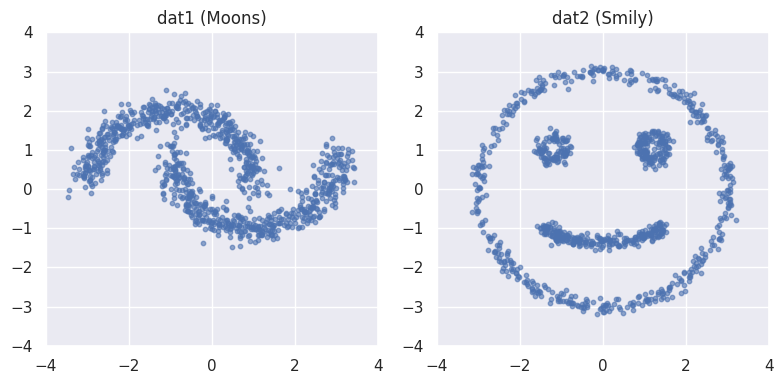

In [3]:
# データの生成
N = 10000
dat1 = generateMoons(N, noise=0.2)
dat2 = generateSmily(N, noise=0.1)

# 可視化（最初の1000個）
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

ax[0].scatter(dat1[:1000, 0], dat1[:1000, 1], alpha=0.6, s=10)
ax[0].set_title("dat1 (Moons)")
ax[0].set_xlim(-4, 4)
ax[0].set_ylim(-4, 4)
ax[0].grid(True)

ax[1].scatter(dat2[:1000, 0], dat2[:1000, 1], alpha=0.6, s=10)
ax[1].set_title("dat2 (Smily)")
ax[1].set_xlim(-4, 4)
ax[1].set_ylim(-4, 4)
ax[1].grid(True)

plt.tight_layout()
plt.show()

#### VAE モデルの定義

`dimX`（入力次元数） → `dimHidden` → `dimZ` x2（muとlogvar） → `dimHidden` → `dimX`

という4層の全結合型ニューラルネット．

In [4]:
### VAE Encoder
#
class VAEEncoder(nn.Module):

    def __init__(self, dimX, dimHidden, dimZ):
        super().__init__()
        self.layer1        = nn.Linear(dimX, dimHidden)
        self.layer2_mu    = nn.Linear(dimHidden, dimZ)
        self.layer2_logvar = nn.Linear(dimHidden, dimZ)

    def forward(self, X):
        Y = self.layer1(X)
        Y = F.relu(Y)
        mu    = self.layer2_mu(Y)
        logvar = self.layer2_logvar(Y)
        return mu, logvar


### VAE Decoder
#
class VAEDecoder(nn.Module):

    def __init__(self, dimZ, dimHidden, dimXt):
        super().__init__()
        self.layer1 = nn.Linear(dimZ, dimHidden)
        self.layer2 = nn.Linear(dimHidden, dimXt)

    def forward(self, Z):
        Y = self.layer1(Z)
        Y = F.relu(Y)
        Xt = self.layer2(Y)
        return Xt

### reparameterization trick
#
def reparameterization(mu, logvar):
    sigma = torch.exp(0.5*logvar)
    eps = torch.randn_like(sigma)
    Z = mu + sigma * eps
    return Z

### VAE
#
class VariationalAE(nn.Module):

    def __init__(self, dimX, dimHidden, dimZ):
        super().__init__()
        self.encoder = VAEEncoder(dimX, dimHidden, dimZ)
        self.decoder = VAEDecoder(dimZ, dimHidden, dimX)

    def forward(self, X):
        mu, logvar = self.encoder(X)
        Z = reparameterization(mu, logvar)
        Xt = self.decoder(Z)
        return Xt, mu, logvar

    def reconstruct(self, X):
        mu, logvar = self.encoder(X)
        Xt = self.decoder(mu)
        return Xt

    def loss(self, Xt, X, mu, logvar):
        SQE = F.mse_loss(Xt, X, reduction='sum')
        KLD = - torch.sum(1 + logvar - mu**2 - logvar.exp())
        return SQE, KLD

#### VAE での実験

In [5]:
# デバイス設定
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')

# 学習データ
X = dat1
X = torch.tensor(X, dtype=torch.float32).to(device)

# ハイパーパラメータ
dimHidden = 256 # 隠れ層ニューロン数
dimZ = 2        # 潜在変数の次元数
beta = 0.1      # KLD項の重み（1が本来のVAE）
nepoch = 100    # 学習エポック数
bsize = 128     # バッチサイズ
lr = 1e-3       # 学習率

# モデルの作成
vae = VariationalAE(2, dimHidden, dimZ).to(device)
optimizer = torch.optim.Adam(vae.parameters(), lr=lr)

# 学習ループ
print(f'epoch  loss    sqe    KLD')
for epoch in range(nepoch):
    perm = torch.randperm(X.shape[0])
    X_shuffled = X[perm]
    loss_sum = sqe_sum = kld_sum = 0.0
    n_sum = 0
    for n in range(0, X.shape[0], bsize):
        # 一つのバッチをモデルに入力して出力を得る
        Xbatch = X_shuffled[n:n+bsize]
        Xt, mu, logvar = vae(Xbatch)
        # 損失を計算
        sqe, kld = vae.loss(Xt, Xbatch, mu, logvar)
        loss = sqe + beta * kld
        n_sum    += len(Xbatch)
        loss_sum += loss.item()
        sqe_sum  += sqe.item()
        kld_sum  += kld.item()
        # 誤差逆伝播学習
        optimizer.zero_grad()   # 勾配をリセット
        loss.backward()         # 誤差逆伝播でパラメータ更新量を計算
        optimizer.step()         # パラメータを更新

    if epoch == 0 or ((epoch + 1) % 10 == 0):
        print(f'{epoch + 1}   {loss_sum/n_sum:.5f}  {sqe_sum/n_sum:.5f}  {kld_sum/n_sum:.5f}')


device: cuda
epoch  loss    sqe    KLD
1   1.76569  1.33152  4.34170
10   0.71545  0.19425  5.21198
20   0.69690  0.19306  5.03842
30   0.68277  0.18656  4.96212
40   0.67233  0.18296  4.89376
50   0.67210  0.18244  4.89665
60   0.65794  0.17375  4.84192
70   0.65508  0.17061  4.84468
80   0.65962  0.17167  4.87953
90   0.65575  0.17041  4.85333
100   0.64800  0.16907  4.78929


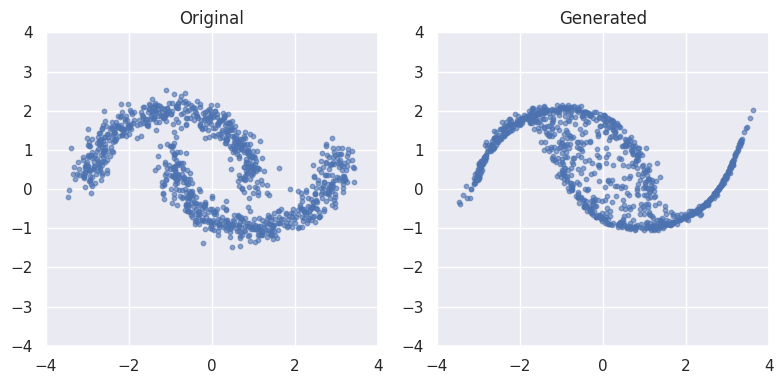

In [6]:
# サンプルを生成
nsamples = 1000
Zgen = np.random.normal(size=nsamples*dimZ).reshape((nsamples, dimZ))
Zgen = torch.tensor(Zgen, dtype=torch.float32).to(device)
XXrec = vae.decoder(Zgen)
XXrec = XXrec.cpu().detach().numpy()
samples = XXrec
original = X.cpu()[:nsamples]

# 可視化
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

ax[0].scatter(original[:, 0], original[:, 1], alpha=0.6, s=10)
ax[0].set_title("Original")
ax[0].set_xlim(-4, 4)
ax[0].set_ylim(-4, 4)
ax[0].grid(True)

ax[1].scatter(samples[:, 0], samples[:, 1], alpha=0.6, s=10)
ax[1].set_title("Generated")
ax[1].set_xlim(-4, 4)
ax[1].set_ylim(-4, 4)
ax[1].grid(True)

plt.tight_layout()
plt.show()

#### 拡散モデルの定義

`dimX` + 1（入力次元数 + 時刻 t） → `dimHidden` → `dimHidden` → `dimX`

という3層の全結合型ニューラルネット．

In [7]:
### 拡散モデルの定義

# 拡散過程
#
class DiffusionProcess():
    def __init__(self, T=1000, beta_start=1e-4, beta_end=0.02, device='cpu'):
        # 拡散過程のノイズスケジュール
        self.T = T
        self.beta = torch.linspace(beta_start, beta_end, T).to(device)
        self.alpha = 1.0 - self.beta
        self.alpha_bar = torch.cumprod(self.alpha, dim=0)

    # q(x_t | x_0):  x_0 と 時刻 t から x_t を計算
    def q_sample(self, x_0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x_0)
        sqrt_ab = self.alpha_bar[t].sqrt().view(-1, 1)
        sqrt_one_minus_ab = (1 - self.alpha_bar[t]).sqrt().view(-1, 1)
        return sqrt_ab * x_0 + sqrt_one_minus_ab * noise

# 逆拡散過程（ノイズ除去過程）
#
class DenoisingModel(nn.Module):
    def  __init__(self, dimX, dimHidden, T=1000):
        super().__init__()
        self.T = T
        # 単純な3層のMLP
        self.net = nn.Sequential(
            nn.Linear(dimX + 1, dimHidden), # 入力: 入力次元 + 時刻 t
            nn.ReLU(),
            nn.Linear(dimHidden, dimHidden),
            nn.ReLU(),
            nn.Linear(dimHidden, dimX),
        )

    def forward(self, x, t):
        # 時刻 t を [0, 1] の値に正規化して入力（positional encodingなし）
        t = t.view(-1, 1) / self.T
        x_input = torch.cat([x, t], dim=1)
        return self.net(x_input)

# 正規乱数に逆拡散過程をT回適用してサンプルを生成
#
@torch.no_grad()
def p_sample_loop(diffproc, denoiser, dimX, N, device='cpu'):
    x = torch.randn(N, dimX).to(device)
    for t in reversed(range(diffproc.T)):
        t_tensor = torch.full((N,), t, device=device, dtype=torch.long)
        z = torch.randn_like(x) if t > 0 else 0
        beta_t      = diffproc.beta[t]
        alpha_t     = diffproc.alpha[t]
        alpha_bar_t = diffproc.alpha_bar[t]
        pred_noise = denoiser(x, t_tensor)
        coef1 = 1 / alpha_t.sqrt()
        coef2 = beta_t / ((1 - alpha_bar_t).sqrt())
        x = coef1 * (x - coef2 * pred_noise) + beta_t.sqrt() * z
    return x

#### 拡散モデルでの実験

In [12]:
# デバイス設定
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'device: {device}')

# 学習データ
X = dat1
X = torch.tensor(X, dtype=torch.float32).to(device)

# ハイパーパラメータ
dimHidden = 256 # 隠れ層ニューロン数
T = 1000        # 拡散ステップ数
nepoch = 200    # 学習エポック数
bsize = 128     # バッチサイズ
lr = 1e-3       # 学習率

# モデルの作成
denoiser = DenoisingModel(2, dimHidden, T=T).to(device)
diffproc = DiffusionProcess(T=T, device=device)
optimizer = optim.Adam(denoiser.parameters(), lr=lr)
loss_fn = nn.MSELoss()

# 学習ループ
for epoch in range(nepoch):
    perm = torch.randperm(X.shape[0])
    X_shuffled = X[perm]
    for n in range(0, X.shape[0], bsize):
        X0 = X_shuffled[n:n+bsize]
        # ノイズを付加したデータを作る
        t = torch.randint(0, T, (X0.shape[0],), device=device).long()
        noise = torch.randn_like(X0)
        Xt = diffproc.q_sample(X0, t, noise)
        # ノイズを予測
        pred_noise = denoiser(Xt, t)
        # 損失を計算して誤差逆伝播学習
        loss = loss_fn(pred_noise, noise)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    if epoch == 0 or ((epoch + 1) % 10 == 0):
        print(f'{epoch + 1}   {loss.item():.5f}')

device: cuda
1   0.42446
10   0.42145
20   0.35614
30   0.52787
40   0.07225
50   0.17687
60   0.40810
70   0.14984
80   0.14830
90   0.31409
100   0.22702
110   0.36562
120   0.32500
130   0.20133
140   0.26143
150   0.46537
160   0.22361
170   0.30214
180   0.51714
190   0.37672
200   0.25329


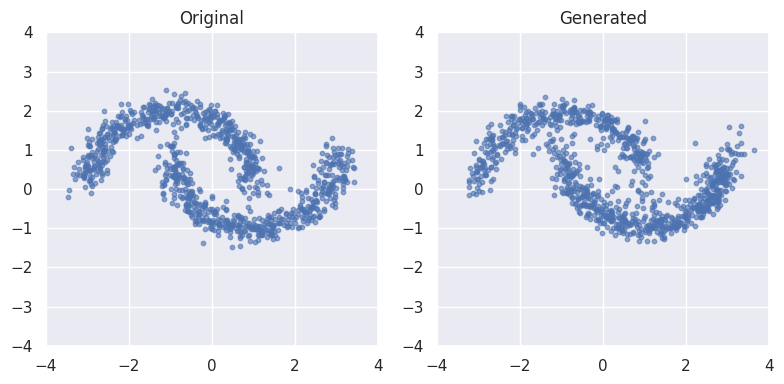

In [13]:
# サンプルを生成
nsamples = 1000
samples = p_sample_loop(diffproc, denoiser, 2, 1000, device=device).cpu().numpy()
original = X.cpu()[:nsamples]

# 可視化
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

ax[0].scatter(original[:, 0], original[:, 1], alpha=0.6, s=10)
ax[0].set_title("Original")
ax[0].set_xlim(-4, 4)
ax[0].set_ylim(-4, 4)
ax[0].grid(True)

ax[1].scatter(samples[:, 0], samples[:, 1], alpha=0.6, s=10)
ax[1].set_title("Generated")
ax[1].set_xlim(-4, 4)
ax[1].set_ylim(-4, 4)
ax[1].grid(True)

plt.tight_layout()
plt.show()

生成ステップを可視化してみる．

In [14]:
# 正規乱数に逆拡散過程をT回適用してサンプルを生成（途中ステップ保存バージョン）
@torch.no_grad()
def p_sample_loop_with_trace(diffproc, denoiser, dimX, N, save_steps, device='cpu'):
    x = torch.randn(N, dimX).to(device)
    traces = {t: x.clone().cpu() for t in save_steps if t == diffproc.T-1}

    for t in reversed(range(diffproc.T)):
        t_tensor = torch.full((N,), t, device=device, dtype=torch.long)
        z = torch.randn_like(x) if t > 0 else 0
        beta_t      = diffproc.beta[t]
        alpha_t     = diffproc.alpha[t]
        alpha_bar_t = diffproc.alpha_bar[t]
        pred_noise = denoiser(x, t_tensor)
        coef1 = 1 / alpha_t.sqrt()
        coef2 = beta_t / ((1 - alpha_bar_t).sqrt())
        x = coef1 * (x - coef2 * pred_noise) + beta_t.sqrt() * z

        if t in save_steps:
            traces[t] = x.clone().cpu()

    return traces

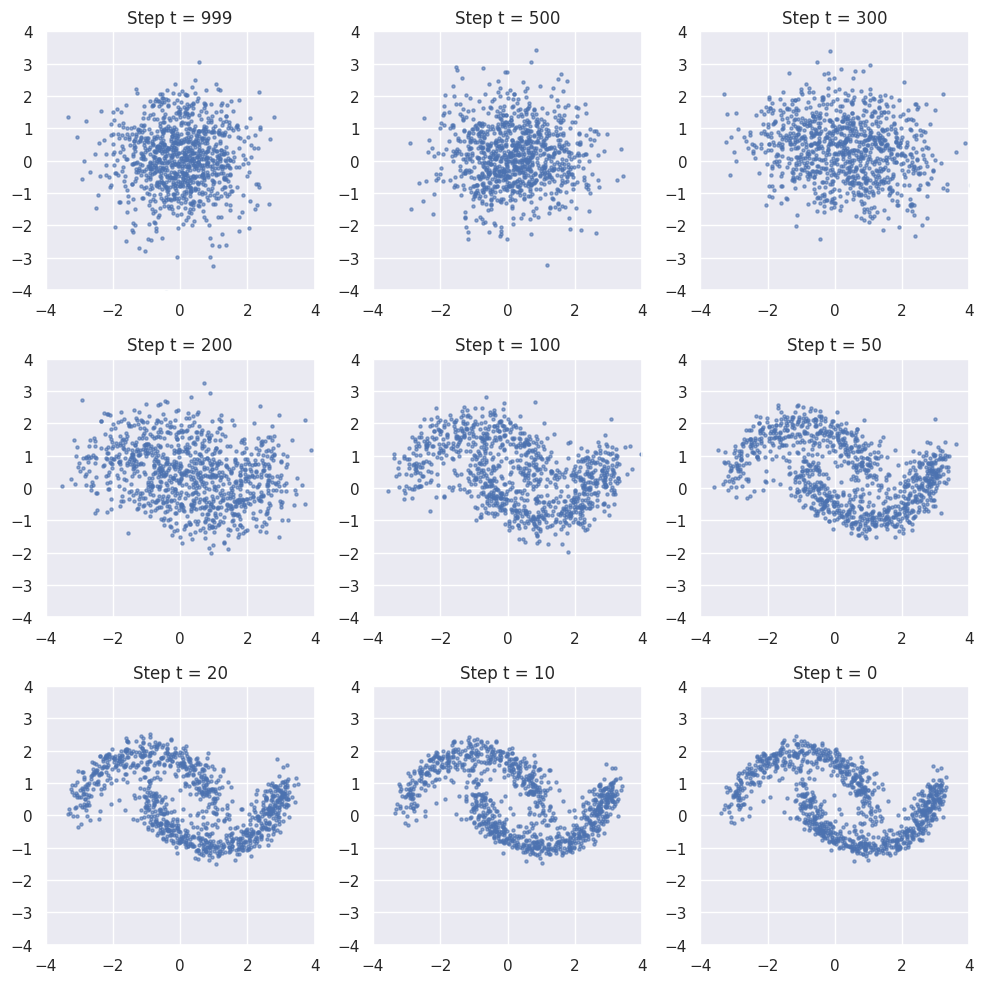

In [15]:
# 可視化するステップ
save_steps = [999, 500, 300, 200, 100, 50, 20, 10, 0]
traces = p_sample_loop_with_trace(diffproc, denoiser, 2, 1000, save_steps, device=device)

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.flatten()

for i, t in enumerate(sorted(traces.keys(), reverse=True)):
    ax = axes[i]
    samples = traces[t].numpy()
    ax.scatter(samples[:, 0], samples[:, 1], s=5, alpha=0.6)
    ax.set_title(f"Step t = {t}")
    ax.grid(True)
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)

plt.tight_layout()
plt.show()